# Superstore Sales Workflow Tutorial

This notebook walks through cleaning the Superstore dataset, designing a relational structure, creating an SQLite database, and running example SQL queries and visualizations.

In [1]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mticker


## 1️) Load and Inspect the Dataset

In [2]:
# reading error codes + research is how you can learn if there is different encoding, as seen below
df = pd.read_csv('../data/Superstore.csv', encoding='ISO-8859-1')
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2013-152156,09-11-2013,12-11-2013,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2013-152156,09-11-2013,12-11-2013,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2013-138688,13-06-2013,17-06-2013,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2012-108966,11-10-2012,18-10-2012,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2012-108966,11-10-2012,18-10-2012,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [3]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [5]:
df["Order Date"] = pd.to_datetime(df["Order Date"], dayfirst=True)
df["Ship Date"] = pd.to_datetime(df["Ship Date"], dayfirst=True)

In [6]:
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.describe()

,Row ID,Order Date,Ship Date,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994,9994,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,2013-04-30 19:20:02.401441024,2013-05-04 18:20:49.229537792,55190.379428,229.858001,3.789574,0.156203,28.656896
min,1.000000,2011-01-04 00:00:00,2011-01-08 00:00:00,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,2012-05-23 00:00:00,2012-05-27 00:00:00,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,2013-06-27 00:00:00,2013-06-30 00:00:00,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,2014-05-15 00:00:00,2014-05-19 00:00:00,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,2014-12-31 00:00:00,2015-01-06 00:00:00,99301.000000,22638.480000,14.000000,0.800000,8399.976000
std,2885.163629,NaN,NaN,32063.693350,623.245101,2.225110,0.206452,234.260108


### Double check some datatypes, and for nulls and duplicates:

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   object        
 2   Order Date     9994 non-null   datetime64[ns]
 3   Ship Date      9994 non-null   datetime64[ns]
 4   Ship Mode      9994 non-null   object        
 5   Customer ID    9994 non-null   object        
 6   Customer Name  9994 non-null   object        
 7   Segment        9994 non-null   object        
 8   Country        9994 non-null   object        
 9   City           9994 non-null   object        
 10  State          9994 non-null   object        
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   object        
 13  Product ID     9994 non-null   object        
 14  Category       9994 non-null   object        
 15  Sub-Category   9994 n

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

This data is incredibly clean - we can see there are no null values and no duplicates. However, there are some dates that could be saved in a better format.

## 2) Data Cleaning

In [12]:
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)
df['Ship Date'] = pd.to_datetime(df['Ship Date'], dayfirst=True)

In [13]:
df.dtypes

Row ID                    int64
Order ID                 object
Order Date       datetime64[ns]
Ship Date        datetime64[ns]
Ship Mode                object
Customer ID              object
Customer Name            object
Segment                  object
Country                  object
City                     object
State                    object
Postal Code               int64
Region                   object
Product ID               object
Category                 object
Sub-Category             object
Product Name             object
Sales                   float64
Quantity                  int64
Discount                float64
Profit                  float64
dtype: object

In [14]:
df.Segment.unique()

array(['Consumer', 'Corporate', 'Home Office'], dtype=object)

In [15]:
df.rename(columns={"Segment":"customer_category"}, inplace=True)
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,customer_category,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2013-152156,2013-11-09,2013-11-12,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2013-152156,2013-11-09,2013-11-12,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2013-138688,2013-06-13,2013-06-17,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2012-108966,2012-10-11,2012-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2012-108966,2012-10-11,2012-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


With real data, it is very likely more cleaning and wrangling would be required. 

## 3) Build Relational Tables

In [19]:
conn = sqlite3.connect('../data/superstore.db')

customers_df = df[['Customer ID','Customer Name','customer_category','City','State','Region', 'Postal Code']].drop_duplicates().rename(columns={
    'Customer ID':'customer_id',
    'Customer Name':'customer_name',
    'City':'city',
    'State':'state',
    'Region':'region',
    'Postal Code':'postal_code'
})

products_df = df[['Product ID','Category','Sub-Category','Product Name']].drop_duplicates().rename(columns={
    'Product ID':'product_id',
    'Category':'category',
    'Sub-Category':'subcategory',
    'Product Name':'product_name'
})

orders_df = df[['Order ID','Order Date','Ship Date','Ship Mode','Customer ID']].drop_duplicates().rename(columns={
    'Order ID':'order_id',
    'Order Date':'order_date',
    'Ship Date':'ship_date',
    'Ship Mode':'ship_mode',
    'Customer ID':'customer_id'
})

order_details_df = df[['Order ID','Product ID','Sales','Quantity','Discount','Profit']].rename(columns={
    'Order ID':'order_id',
    'Product ID':'product_id'
})

customers_df.to_sql('customers', conn, index=False, if_exists='replace')
products_df.to_sql('products', conn, index=False, if_exists='replace')
orders_df.to_sql('orders', conn, index=False, if_exists='replace')
order_details_df.to_sql('order_details', conn, index=False, if_exists='replace')
conn.commit()

## 4) Make Some Queries!

### Which customer segments bring in the most revenue and profit?

In [ ]:
query1 = """ SELECT 
    c.customer_category,
    ROUND(SUM(od.sales), 2) AS total_sales,
    ROUND(SUM(od.profit), 2) AS total_profit
FROM order_details od
JOIN orders o ON od.order_id = o.order_id
JOIN customers c ON o.customer_id = c.customer_id
GROUP BY c.customer_category
ORDER BY total_sales DESC;
"""
result1 = pd.read_sql(query1, conn)
result1

### What are the top 10 customers by total sales?

In [20]:
query2 = """
SELECT
    c.customer_id,
    c.customer_name,
    SUM(od.Sales) AS total_sales
FROM customers c
JOIN orders o
    ON c.customer_id = o.customer_id
JOIN order_details od
    ON o.order_id = od.order_id
GROUP BY c.customer_id, c.customer_name
ORDER BY total_sales DESC
LIMIT 10;
"""
result2 = pd.read_sql(query2, conn)
result2

,customer_id,customer_name,total_sales
0,KL-16645,Ken Lonsdale,155927.519
1,SE-20110,Sanjit Engle,134303.818
2,CL-12565,Clay Ludtke,130566.552
3,AB-10105,Adrian Barton,130262.139
4,SC-20095,Sanjit Chand,127281.006
5,SM-20320,Sean Miller,125215.250
6,EH-13765,Edward Hooks,123730.560
7,GT-14710,Greg Tran,118201.200
8,SV-20365,Seth Vernon,114709.500
9,JL-15835,John Lee,107799.153


### Which product categories and subcategories are the most profitable overall?

In [23]:
query3 = """
SELECT
    p.category,
    p.subcategory,
    ROUND(SUM(od.Profit), 2) AS total_profit
FROM products p
JOIN order_details od
    ON p.product_id = od.product_id
GROUP BY
    p.category,
    p.subcategory
ORDER BY
    total_profit DESC;
"""
result3 = pd.read_sql(query3, conn)
result3

,category,subcategory,total_profit
0,Technology,Copiers,55617.82
1,Technology,Accessories,48359.05
2,Technology,Phones,46936.19
3,Office Supplies,Paper,36994.53
4,Office Supplies,Binders,30373.20
5,Furniture,Chairs,26707.65
6,Office Supplies,Storage,21408.70
7,Office Supplies,Appliances,18514.49
8,Furniture,Furnishings,14569.59
9,Office Supplies,Envelopes,6964.18


### What is the average discount given per category?

In [25]:
query4 = query4 = """
SELECT
    p.category,
    ROUND(AVG(od.Discount), 2) AS average_discount
FROM products p
JOIN order_details od
    ON p.product_id = od.product_id
GROUP BY p.category
ORDER BY average_discount DESC;
"""

result4 = pd.read_sql(query4, conn)
result4
result4 = pd.read_sql(query4, conn)
result4

,category,average_discount
0,Furniture,0.17
1,Office Supplies,0.16
2,Technology,0.13


### Which states or regions contribute the most to total sales?

In [28]:
query5 = """
SELECT
    c.region,
    c.state,
    ROUND(SUM(od.Sales), 2) AS total_sales
FROM customers c
JOIN orders o
    ON c.customer_id = o.customer_id
JOIN order_details od
    ON o.order_id = od.order_id
GROUP BY
    c.region,
    c.state
ORDER BY
    total_sales DESC;
"""
result5 = pd.read_sql(query5, conn)
result5

,region,state,total_sales
0,West,California,3314837.69
1,East,New York,1859365.37
2,Central,Texas,1547925.76
3,East,Pennsylvania,886105.68
4,West,Washington,862298.69
5,Central,Illinois,843352.76
6,East,Ohio,707747.69
7,South,Florida,635637.78
8,South,North Carolina,437938.43
9,Central,Michigan,432428.02


### How many orders were shipped late (where Ship Date > Order Date + 3 days)?

In [27]:
query6 = query6 = """
SELECT
    COUNT(*) AS late_orders
FROM orders
WHERE date(ship_date) > date(order_date, '+3 days');
"""

result6 = pd.read_sql(query6, conn)
result6

,late_orders
0,3391


### Which month or year had the highest total sales?

In [30]:
query7 = query7 = """
SELECT
    strftime('%Y', o.order_date) AS year,
    ROUND(SUM(od.Sales), 2) AS total_sales
FROM orders o
JOIN order_details od
    ON o.order_id = od.order_id
GROUP BY year
ORDER BY total_sales DESC;
"""

result7 = pd.read_sql(query7, conn)
result7
result7 = pd.read_sql(query7, conn)
result7

,year,total_sales
0,2014,733947.02
1,2013,608473.83
2,2011,484247.50
3,2012,470532.51


### What are the most frequently ordered products?

In [32]:
query8 = """
SELECT
    p.product_name,
    COUNT(od.order_id) AS times_ordered
FROM products p
JOIN order_details od
    ON p.product_id = od.product_id
GROUP BY
    p.product_name
ORDER BY
    times_ordered DESC
LIMIT 10;
"""
result8 = pd.read_sql(query8, conn)
result8

,product_name,times_ordered
0,Staples,227
1,Avery Non-Stick Binders,20
2,Xerox 1908,19
3,Xerox 1881,19
4,Logitech P710e Mobile Speakerphone,18
5,KI Adjustable-Height Table,18
6,Imation 16GB Mini TravelDrive USB 2.0 Flash Drive,18
7,Storex Dura Pro Binders,17
8,"Executive Impressions 13"" Clairmont Wall Clock",16
9,"Eldon Image Series Desk Accessories, Burgundy",16


### Which customers placed more than 5 orders total?

In [34]:
query9 = query9 = """
SELECT
    c.customer_id,
    c.customer_name,
    COUNT(o.order_id) AS total_orders
FROM customers c
JOIN orders o
    ON c.customer_id = o.customer_id
GROUP BY
    c.customer_id,
    c.customer_name
HAVING
    COUNT(o.order_id) > 5
ORDER BY
    total_orders DESC;
"""

result9 = pd.read_sql(query9, conn)
result9
result9 = pd.read_sql(query9, conn)
result9

,customer_id,customer_name,total_orders
0,EP-13915,Emily Phan,289
1,EA-14035,Erin Ashbrook,169
2,JE-15745,Joel Eaton,169
3,SH-19975,Sally Hughsby,169
4,ZC-21910,Zuschuss Carroll,169
...,...,...,...
742,SS-20515,Shirley Schmidt,9
743,SW-20350,Sean Wendt,9
744,TM-21490,Tony Molinari,9
745,TT-21265,Tim Taslimi,9


### What’s the profit margin (profit ÷ sales) by category or segment?

In [35]:
query10 = query10 = """
SELECT
    p.category,
    ROUND(SUM(od.Profit), 2) AS total_profit,
    ROUND(SUM(od.Sales), 2) AS total_sales,
    ROUND(SUM(od.Profit) * 1.0 / SUM(od.Sales), 4) AS profit_margin
FROM products p
JOIN order_details od
    ON p.product_id = od.product_id
GROUP BY
    p.category
ORDER BY
    profit_margin DESC;
"""

result10 = pd.read_sql(query10, conn)
result10
result10 = pd.read_sql(query10, conn)
result10

,category,total_profit,total_sales,profit_margin
0,Technology,153415.70,893633.28,0.1717
1,Office Supplies,126113.35,736748.59,0.1712
2,Furniture,20098.89,764284.65,0.0263


### 5) Visualize it!

From your ten results, select at least 4 to utilize in a meaningful visualization. 

In [21]:
# example using result1
plt.figure(figsize=(10,6))
colors = ["#a7adaa", "#a7adaa", "#f74141" ]
sns.barplot(result1, x='customer_category', y='total_sales', palette=colors, hue='customer_category', legend=False)
plt.title('Small Offices, Smaller Sales: The Home Office Gap',fontsize=18)
plt.xlabel(None)
plt.ylabel('Total Sales ($USD)')

#for those wondering how to get rid of scientific notation! Set style to plain:
plt.ticklabel_format(style='plain', axis='y')

#mticker is a great library for helping tick mark formatting, such as adding commas and dollar signs in this case
ax = plt.gca()
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

#using the seaborn library, despining is way easier!
sns.despine()
plt.show()


NameError: name 'result1' is not defined

<Figure size 1000x600 with 0 Axes>

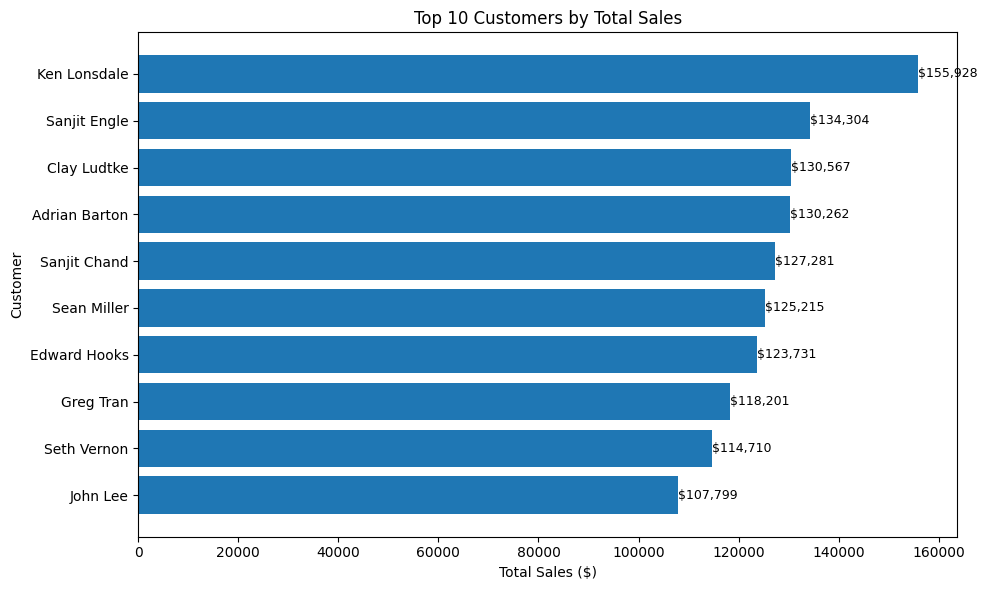

In [22]:
# visualization one code here

import matplotlib.pyplot as plt

plot_data = result2.sort_values(by="total_sales", ascending=True)

plt.figure(figsize=(10, 6))
bars = plt.barh(plot_data["customer_name"], plot_data["total_sales"])

plt.title("Top 10 Customers by Total Sales")
plt.xlabel("Total Sales ($)")
plt.ylabel("Customer")

for bar in bars:
    plt.text(
        bar.get_width(),
        bar.get_y() + bar.get_height()/2,
        f"${bar.get_width():,.0f}",
        va="center",
        ha="left",
        fontsize=9
    )

plt.tight_layout()
plt.show()

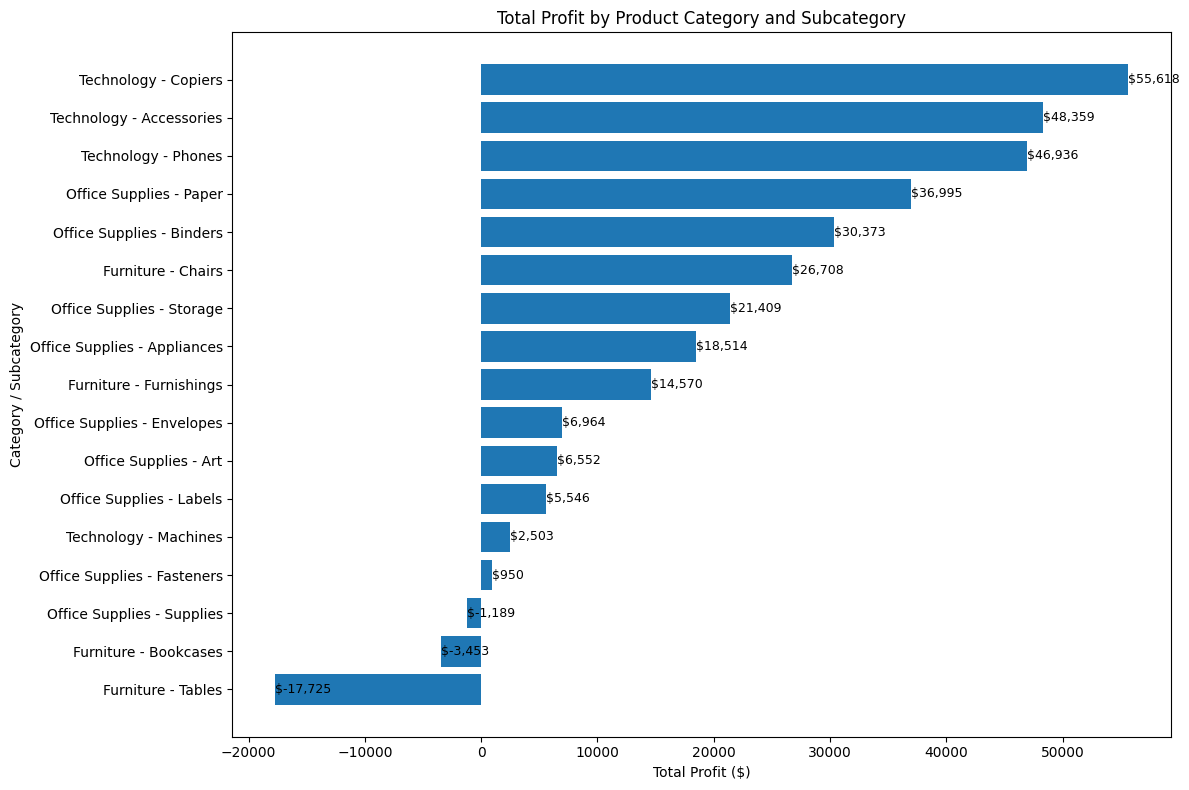

In [24]:
# visualization two code here

import matplotlib.pyplot as plt

# Create a combined label
result3["Category / Subcategory"] = (
    result3["category"] + " - " + result3["subcategory"]
)

# Sort so the highest profit appears at the top
plot_data = result3.sort_values("total_profit", ascending=True)

plt.figure(figsize=(12, 8))

bars = plt.barh(
    plot_data["Category / Subcategory"],
    plot_data["total_profit"]
)

plt.title("Total Profit by Product Category and Subcategory")
plt.xlabel("Total Profit ($)")
plt.ylabel("Category / Subcategory")

# Add value labels to each bar
for bar in bars:
    width = bar.get_width()
    plt.text(
        width,
        bar.get_y() + bar.get_height() / 2,
        f"${width:,.0f}",
        va="center",
        ha="left",
        fontsize=9
    )

plt.tight_layout()
plt.show()

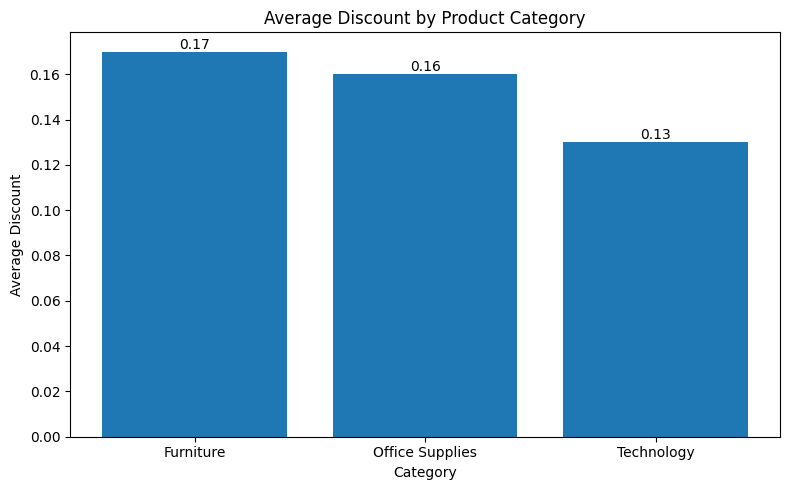

In [26]:
# visualization three code here

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

bars = plt.bar(result4["category"], result4["average_discount"])

plt.title("Average Discount by Product Category")
plt.xlabel("Category")
plt.ylabel("Average Discount")

# Add labels above each bar
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{height:.2f}",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.tight_layout()
plt.show()

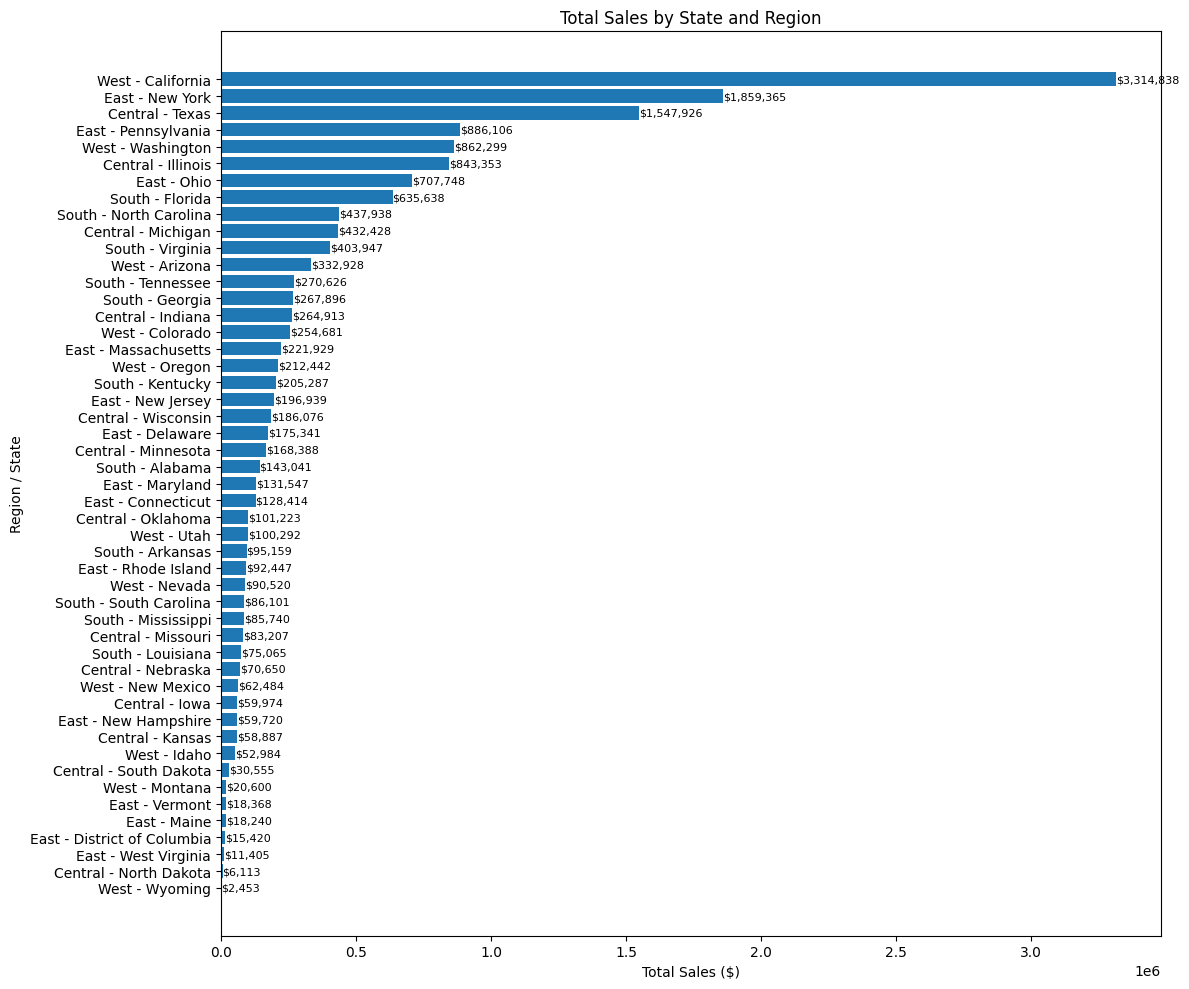

In [29]:
# visualization four code here

import matplotlib.pyplot as plt

# Create labels combining region and state
result5["Region / State"] = result5["region"] + " - " + result5["state"]

# Sort so the largest sales appear at the top
plot_data = result5.sort_values("total_sales", ascending=True)

plt.figure(figsize=(12, 10))

bars = plt.barh(
    plot_data["Region / State"],
    plot_data["total_sales"]
)

plt.title("Total Sales by State and Region")
plt.xlabel("Total Sales ($)")
plt.ylabel("Region / State")

# Add sales labels
for bar in bars:
    width = bar.get_width()
    plt.text(
        width,
        bar.get_y() + bar.get_height()/2,
        f"${width:,.0f}",
        va="center",
        ha="left",
        fontsize=8
    )

plt.tight_layout()
plt.show()

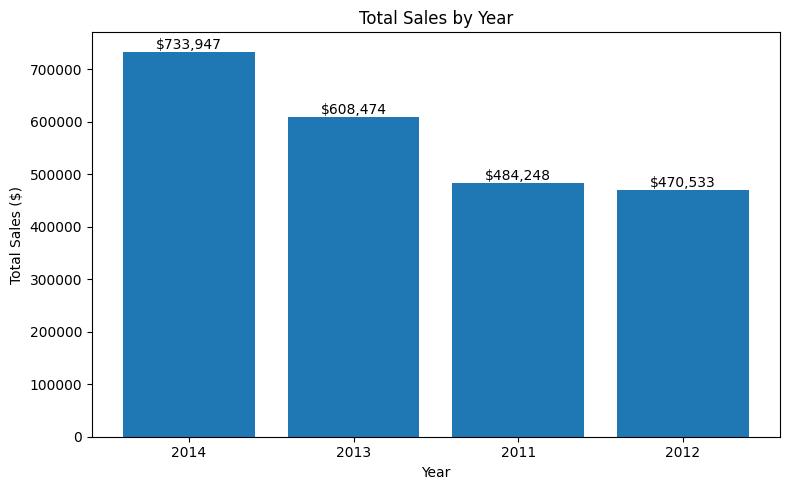

In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

bars = plt.bar(result7["year"], result7["total_sales"])

plt.title("Total Sales by Year")
plt.xlabel("Year")
plt.ylabel("Total Sales ($)")

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"${bar.get_height():,.0f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

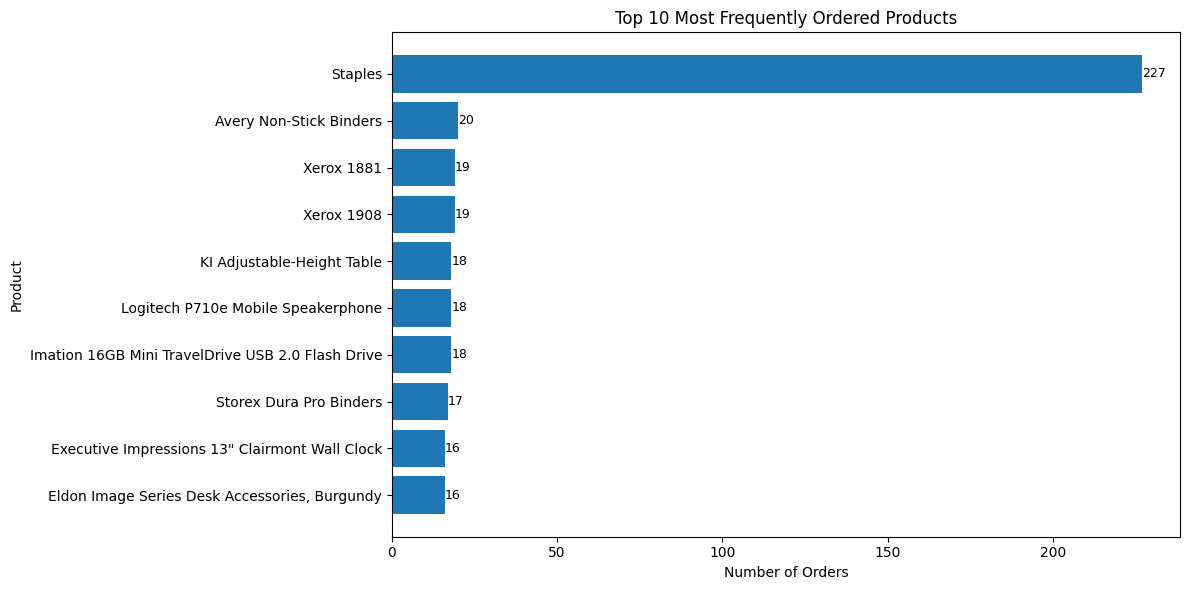

In [33]:
import matplotlib.pyplot as plt

# Sort so the most ordered product appears at the top
plot_data = result8.sort_values("times_ordered", ascending=True)

plt.figure(figsize=(12, 6))

bars = plt.barh(
    plot_data["product_name"],
    plot_data["times_ordered"]
)

plt.title("Top 10 Most Frequently Ordered Products")
plt.xlabel("Number of Orders")
plt.ylabel("Product")

# Add labels to each bar
for bar in bars:
    width = bar.get_width()
    plt.text(
        width,
        bar.get_y() + bar.get_height()/2,
        f"{int(width)}",
        va="center",
        ha="left",
        fontsize=9
    )

plt.tight_layout()
plt.show()